<a href="https://colab.research.google.com/github/mohanasudhashanmugam/DeepLearning/blob/main/Modified_train_theft_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
#!kaggle datasets download -d kipshidze/shoplifting-video-dataset
#!unzip -q shoplifting-video-dataset.zip -d ./local_colab_storage

In [35]:
!ls /content/local_colab_storage/normal | wc -l

90


In [36]:
!ls /content/local_colab_storage/shoplifting | wc -l

92


In [37]:
import cv2
import os
import numpy as np
import argparse
from imutils import paths
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [38]:
# construct the argument parser and parse the arguments
ap = argparse.ArgumentParser()

ap.add_argument("-d", "--dataset",
	default="/content/local_colab_storage/",
	help="path to input dataset")
args_namespace, unknown = ap.parse_known_args()


# Convert to a dictionary
args = vars(args_namespace)

In [39]:
video_extensions = (
    ".mp4",
    ".avi",
    ".mkv",
    ".mov",
    ".wmv",
    ".flv",
    ".webm"
)

video_paths = list(paths.list_files(
    args["dataset"],
    validExts=video_extensions
))

video_labels = []

for video_path in video_paths:
    label = video_path.split(os.path.sep)[-2]
    video_labels.append(label)

print("Total videos:", len(video_paths))
print("Labels:", set(video_labels))

Total videos: 182
Labels: {'normal', 'shoplifting'}


In [40]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(video_labels)

print("Classes:", label_encoder.classes_)
print("Encoded labels:", y)


from tensorflow.keras.utils import to_categorical

y = to_categorical(y, num_classes=2)

print(y)

Classes: ['normal' 'shoplifting']
Encoded labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1.

In [41]:
from sklearn.model_selection import train_test_split

train_paths, test_paths, train_labels, test_labels = train_test_split(
    video_paths,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training videos:", len(train_paths))
print("Testing videos:", len(test_paths))

Training videos: 145
Testing videos: 37


In [42]:
import tensorflow as tf

class VideoDataGenerator(tf.keras.utils.Sequence):

    def __init__(
        self,
        video_paths,
        labels,
        batch_size=4,
        max_frames=32,
        resize_dim=(224, 224),
        shuffle=True
    ):
        self.video_paths = video_paths
        self.labels = labels
        self.batch_size = batch_size
        self.max_frames = max_frames
        self.resize_dim = resize_dim
        self.shuffle = shuffle

        self.indices = np.arange(len(self.video_paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.video_paths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def process_video(self, video_path):

        cap = cv2.VideoCapture(video_path)

        total_frames = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        if total_frames <= 0:
            cap.release()
            return np.zeros(
                (self.max_frames, *self.resize_dim, 3),
                dtype=np.float32
            )

        frame_indices = np.linspace(
            0,
            total_frames - 1,
            self.max_frames,
            dtype=int
        )

        video_frames = []

        for frame_idx in frame_indices:

            cap.set(
                cv2.CAP_PROP_POS_FRAMES,
                frame_idx
            )

            success, frame = cap.read()

            if not success:
                break

            frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            frame = cv2.resize(
                frame,
                self.resize_dim
            )

            frame = frame.astype(
                np.float32
            ) / 255.0

            video_frames.append(frame)

        cap.release()

        # Make sure every video has exactly 32 frames
        while len(video_frames) < self.max_frames:

            video_frames.append(
                video_frames[-1].copy()
                if video_frames
                else np.zeros(
                    (*self.resize_dim, 3),
                    dtype=np.float32
                )
            )

        return np.array(
            video_frames,
            dtype=np.float32
        )

    def __getitem__(self, index):

        start = index * self.batch_size
        end = min(
            start + self.batch_size,
            len(self.video_paths)
        )

        batch_indices = self.indices[start:end]

        X_batch = []
        y_batch = []

        for i in batch_indices:

            video = self.process_video(
                self.video_paths[i]
            )

            X_batch.append(video)
            y_batch.append(self.labels[i])

        X_batch = np.array(
            X_batch,
            dtype=np.float32
        )

        y_batch = np.array(y_batch, dtype=np.float32)

        ##y_batch = tf.keras.utils.to_categorical(y_batch,num_classes=2)

        return X_batch, y_batch

In [43]:
train_generator = VideoDataGenerator(
    train_paths,
    train_labels,
    batch_size=2,
    max_frames=32,
    resize_dim=(224, 224),
    shuffle=True
)

test_generator = VideoDataGenerator(
    test_paths,
    test_labels,
    batch_size=2,
    max_frames=32,
    resize_dim=(224, 224),
    shuffle=False
)

In [44]:
X_batch, y_batch = train_generator[0]

print("Batch X shape:", X_batch.shape)
print("Batch y shape:", y_batch.shape)
print("Batch X dtype:", X_batch.dtype)
print("Batch X memory:",
      X_batch.nbytes / (1024**2),
      "MB")

Batch X shape: (2, 32, 224, 224, 3)
Batch y shape: (2, 2)
Batch X dtype: float32
Batch X memory: 36.75 MB


In [45]:

from tensorflow.keras import layers, models

aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomContrast(0.1)
])

# 1. Base CNN to extract features from a single frame
# We use MobileNetV2 because it is lightweight and fast

base_cnn = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_cnn.trainable = False  # Freeze weights as we don't destroy pre-trained weights by new training data during backpropagation

# Flatten the CNN output to a vector
pooling_layer = layers.GlobalAveragePooling2D()(base_cnn.output)
feature_extractor = models.Model(
    inputs=base_cnn.input,
    outputs=pooling_layer
)
# 2. Complete Video Model
video_input = layers.Input(
    shape=(32, 224, 224, 3)
)
# TimeDistributed applies the CNN to all frames individually
augmented_input = layers.TimeDistributed(aug)(video_input)
encoded_frames = layers.TimeDistributed(
    feature_extractor
)(augmented_input)

# LSTM tracks the movement across the timeline
#x = layers.LSTM(
 #   64,
  #  dropout=0.5
#)(encoded_frames)

x = layers.LSTM(
    128,
    dropout=0.3
)(encoded_frames)

#x = layers.Dense(32,activation='relu')(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)

# # Output layer: Sigmoid activation for binary classification (0 or 1)
output = layers.Dense(
    2,
    activation='softmax'
)(x)

model = models.Model(
    inputs=video_input,
    outputs=output
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 32, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 32, 224, 224,   │             0 │
│ (TimeDistributed)               │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 32, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,987,778 (11.40 MB)

 Trainable params: 729,794 (2.78 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [46]:
## Run training for 30 to 50 epochs, but use an EarlyStopping callback.
#This tells Colab to keep training as long as the validation loss is improving, and automatically stop if it plateaus, saves time.

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)


history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=30
    #,
    # callbacks=[early_stop]
)

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - accuracy: 0.5103 - loss: 0.7294 - val_accuracy: 0.5946 - val_loss: 0.6634
Epoch 2/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.5586 - loss: 0.7072 - val_accuracy: 0.4865 - val_loss: 0.6996
Epoch 3/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.5586 - loss: 0.6885 - val_accuracy: 0.5135 - val_loss: 0.6783
Epoch 4/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.6000 - loss: 0.6906 - val_accuracy: 0.5676 - val_loss: 0.6349
Epoch 5/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.6345 - loss: 0.6364 - val_accuracy: 0.5946 - val_loss: 0.6428
Epoch 6/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.6621 - loss: 0.6177 - val_accuracy: 0.6216 - val_loss: 0.5949
Epoch 7/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.6414 - loss: 0.6335 - val_accuracy: 0.7568 - val_loss: 0.5813
Epoch 8/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.6276 - loss: 0.6358 - val_accuracy: 0.6216 - v

In [47]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Get raw probability predictions (numbers between 0.0 and 1.0)
predictions = model.predict(test_generator)
print(predictions)

19/19 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step
[[0.04901079 0.9509892 ]
 [0.16893275 0.8310672 ]
 [0.14194013 0.8580599 ]
 [0.07823477 0.9217652 ]
 [0.23304    0.76695997]
 [0.6402024  0.35979763]
 [0.04972496 0.95027506]
 [0.10986863 0.8901314 ]
 [0.107058   0.892942  ]
 [0.19509812 0.80490184]
 [0.09204262 0.9079574 ]
 [0.68161964 0.31838036]
 [0.02632641 0.9736736 ]
 [0.7886123  0.21138766]
 [0.09127183 0.9087282 ]
 [0.07632139 0.9236786 ]
 [0.75497633 0.24502362]
 [0.84122086 0.15877911]
 [0.09454381 0.9054562 ]
 [0.04340552 0.9565945 ]
 [0.05063193 0.9493681 ]
 [0.45645136 0.54354864]
 [0.18062952 0.8193705 ]
 [0.97862154 0.02137843]
 [0.22172935 0.77827066]
 [0.55247194 0.44752806]
 [0.04486003 0.95513994]
 [0.17743231 0.8225677 ]
 [0.7269735  0.27302656]
 [0.0400969  0.9599031 ]
 [0.67069757 0.32930243]
 [0.58812195 0.41187802]
 [0.92234164 0.07765837]
 [0.01901367 0.9809863 ]
 [0.60097903 0.39902094]
 [0.09909171 0.90090823]
 [0.08584705 0.9141529 ]]


In [48]:
# 2. Convert probabilities to binary choices: if > 0.5, it's Shoplifting (1), else Normal (0)
##binary_predictions = (predictions > 0.5).astype(int)

binary_predictions = np.argmax(predictions, axis=1)

# ============================================================
# TO GET TRUE TEST LABELS
#
# test_generator labels correspond to the video order.
# ============================================================

true_labels = []

for i in range(len(test_generator)):

    _, batch_labels = test_generator[i]

    true_labels.extend(
        batch_labels.astype(int)
    )


true_labels = np.array(
    true_labels
)

# Convert y_test from 2 columns to 1 column
true_labels = np.argmax(true_labels, axis=1)

print(binary_predictions)

print("true_labels", true_labels)

[1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 0 0 1 1 1 1 1 0 1 0 1 1 0 1 0 0 0 1 0 1 1]
true_labels [1 0 0 1 1 0 1 1 1 0 1 0 1 0 1 1 0 0 1 0 0 0 0 0 1 1 1 1 0 1 0 0 0 1 0 1 1]


In [49]:
print("--- Confusion Matrix ---")
cm=confusion_matrix(true_labels, binary_predictions)
print(cm)

--- Confusion Matrix ---
[[11  7]
 [ 1 18]]


In [50]:
print("\n--- Classification Report ---")
print(classification_report(true_labels, binary_predictions, target_names=['Normal', 'Shoplifting']))


--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.92      0.61      0.73        18
 Shoplifting       0.72      0.95      0.82        19

    accuracy                           0.78        37
   macro avg       0.82      0.78      0.78        37
weighted avg       0.82      0.78      0.78        37



In [51]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

import os

folder = os.path.expanduser(
    "~/Desktop/AI - Mohana/Deep Learning/DL Capstone project"
)

os.makedirs(folder, exist_ok=True)

model_path = os.path.join(
    folder,
    "shoplifting_detection_final.keras"
)

model.save(model_path)

print("Saved successfully!")
print(model_path)

##model.save("/Users/Max/Desktop/AI - Mohana/Deep Learning/DL Capstone project/shoplifting_detection_final.keras")
##print("\nFinal model saved successfully.")



Saved successfully!
/root/Desktop/AI - Mohana/Deep Learning/DL Capstone project/shoplifting_detection_final.keras


In [52]:
from google.colab import files
files.download("/root/Desktop/AI - Mohana/Deep Learning/DL Capstone project/shoplifting_detection_final.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

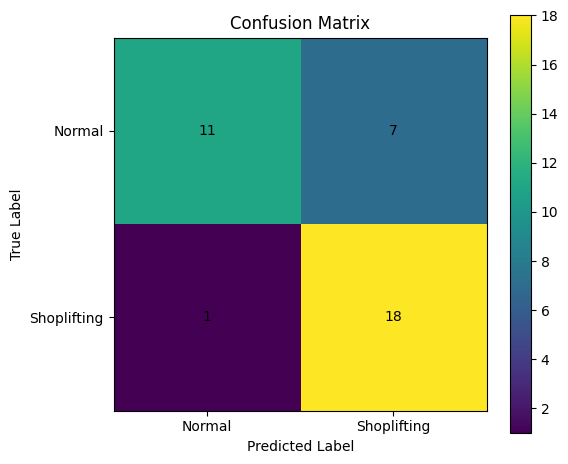

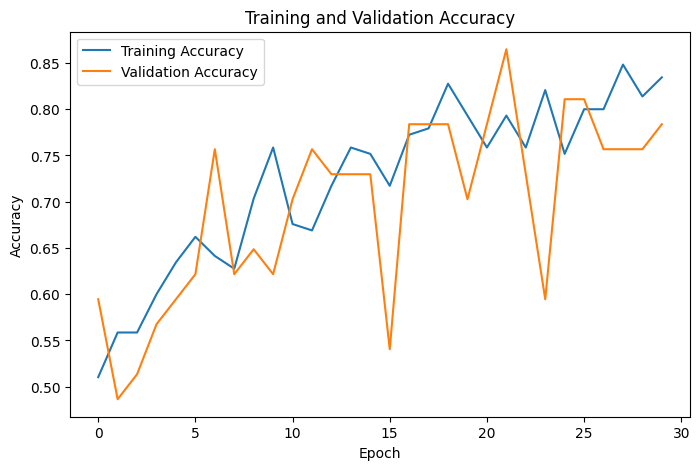

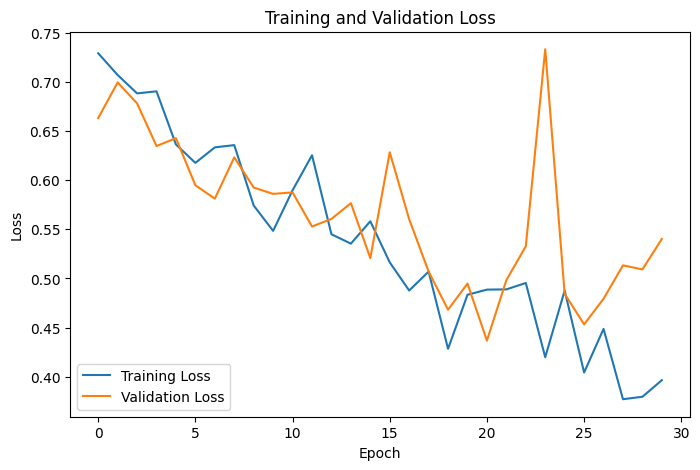

In [53]:
# ============================================================
#  DISPLAY CONFUSION MATRIX AS A HEATMAP
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["Normal", "Shoplifting"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Shoplifting"]
)


for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.colorbar()

plt.tight_layout()

plt.show()


# ============================================================
#  TRAINING / VALIDATION ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Training and Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()


# ============================================================
#  TRAINING / VALIDATION LOSS GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Training and Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()


# ============================================================
# END OF PROJECT
# ============================================================
